In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("car_ownership.csv")

print(df.shape)

df.head()

(27, 2)


,monthly_salary,owns_car
0,22000,0
1,25000,0
2,47000,1
3,52000,0
4,46000,1


In [2]:
from sklearn.model_selection import train_test_split

# Features and Target selection
X = df[["monthly_salary"]] # Feature(s)
y = df["owns_car"] # Target

# Create train test split for given data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((18, 1), (9, 1), (18,), (9,))

In [3]:
# Import sklearn library for logistic Regression
from sklearn.linear_model import LogisticRegression

# Create model
model = LogisticRegression()

# Train the model using training data
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [4]:
# Evaluate the model on test data using score method
model.score(X_test, y_test)

0.8888888888888888

So the score indicates that model was able to predict 88% data correctly.

In [5]:
y_pred = model.predict(X_test)

y_pred

array([1, 0, 1, 0, 0, 0, 0, 1, 0])

In [6]:
y_test.to_list()

[1, 0, 1, 0, 0, 0, 1, 1, 0]

So as we can see 8 out of 9 predicts were correct.

In [7]:
8/9

0.8888888888888888

Now let's calculate precision and recall using classification report method

In [8]:
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.75      0.86         4

    accuracy                           0.89         9
   macro avg       0.92      0.88      0.88         9
weighted avg       0.91      0.89      0.89         9



Here f1-score =  2*((precision*recall)/(precision+recall))

Now let's talk about confusion matrix

In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[5, 0],
       [1, 3]])

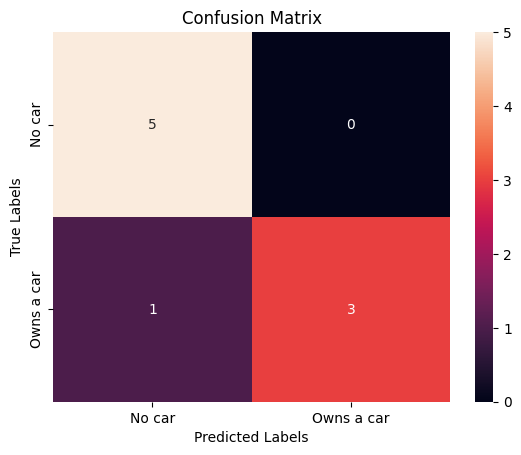

In [25]:
classes = ["No car", "Owns a car"]
sns.heatmap(cm, annot=True, xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()